# Monthly Orders Analysis
EDA on monthly order trends across time, state, and category

## Objective
- How do total revenue, order count, and average revenue per item evolve over time?
- Is SP's revenue dominance consistent throughout the analysis period, or is it growing or declining?
- Do different categories follow different growth and seasonal patterns over time?

## Approach
- Decompose monthly time series for count, total revenue, and average revenue to identify trend and seasonal components
- Analyze SP vs Other States as the state dimension, based on findings from the state revenue analysis
- Analyze the top 7 categories as the category dimension, based on findings from the category revenue analysis
- Compare category share over time to assess whether the revenue mix is stable

## Key Findings
- Count and total revenue show consistent upward trends. No clear seasonality pattern can be confirmed for these metrics due to limited data (only 20 months).
- Average revenue per order shows a strong seasonality pattern, but no clear trends.
- SP maintains a stable share of around 65% of total revenue and count throughout the period. Its dominance is structural and does not grow or erode over time.
- health_beauty is the consistently dominant category. The top 7 categories together maintain a stable combined share of around 50% of total revenue with no single category gaining dominance.

In [1]:
import sys
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

ROOT = Path("..").resolve()
sys.path.insert(0, str(ROOT))
from utils.time_series_plots import (
	monthly_agg,
	plot_overview_trends, plot_category_share_pct,
	plot_timeseries_with_ma, plot_stacked_pct,
	plot_category_timeseries, plot_detrended,
)
from data.connection import get_connection

conn = get_connection()

In [2]:
with open(f"{ROOT}/sql/monthly_orders.sql") as f:
    sql = f.read()

df = pd.read_sql(sql, conn)

df.head()

,order_purchase_timestamp,order_id,seller_id,state,category,revenue
0,2017-10-02 10:56:33,e481f51cbdc54678b7cc49136f2d6af7,3504c0cb71d7fa48d967e0e4c94d59d9,SP,housewares,38.71
1,2018-07-24 20:41:37,53cdb2fc8bc7dce0b6741e2150273451,289cdb325fb7e7f891c38608bf9e0962,SP,perfumery,141.46
2,2018-08-08 08:38:49,47770eb9100c2d0c44946d9cf07ec65d,4869f7a5dfa277a7dca6462dcf3b52b2,SP,auto,179.12
3,2017-11-18 19:28:06,949d5b44dbf5de918fe9c16f97b45f8a,66922902710d126a0e7d26b0e3805106,MG,pet_shop,72.20
4,2018-02-13 21:18:39,ad21c59c0840e6cb83a9ceb5573f8159,2c9e548be18521d1c43cde1c582c6de8,SP,stationery,28.62


## Overview
Count and total revenue show a clear upward trend throughout the analysis period. Average revenue per item is flat, confirming that overall growth is volume-driven rather than price-driven. No clear seasonality pattern can be confirmed for count or total revenue due to the limited data range (20 months).

In [3]:
df["order_purchase_timestamp"] = pd.to_datetime(df["order_purchase_timestamp"])
df["month_year"] = df["order_purchase_timestamp"].dt.to_period("M")

### Monthly Count, Mean, and Total Revenue Trends
Count and total revenue grow steadily with a visible upward trend. Average revenue exhibit a strong seasonality pattern, but no trend.

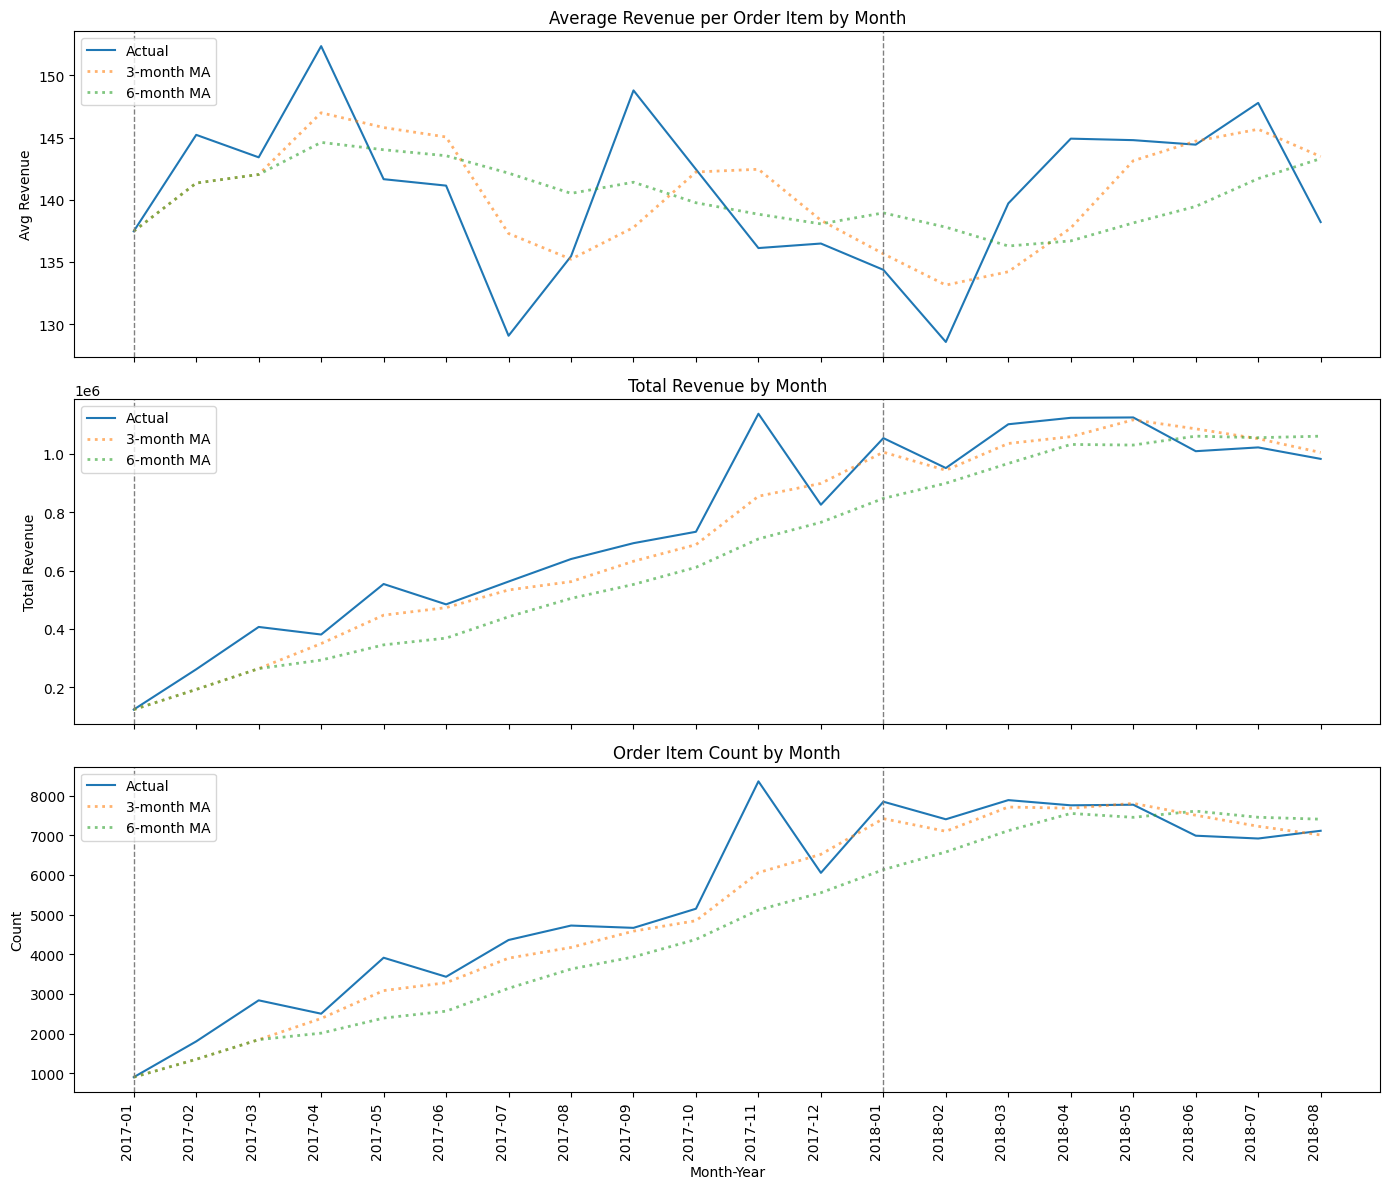

In [4]:
revenue_by_month = df.groupby("month_year")["revenue"].agg(["mean", "sum"]).sort_index()
count_by_month = df.groupby("month_year").size().sort_index()
x_labels = revenue_by_month.index.astype(str)

series = {
	"avg_revenue": revenue_by_month["mean"],
	"total_revenue": revenue_by_month["sum"],
	"count": count_by_month,
}
titles = ["Average Revenue per Order Item by Month", "Total Revenue by Month", "Order Item Count by Month"]
ylabels = ["Avg Revenue", "Total Revenue", "Count"]

year_boundary_positions = [i for i, label in enumerate(x_labels) if label.endswith("-01")]

plot_overview_trends(series, titles, ylabels, x_labels, year_boundary_positions)

### Seasonality Test for Total Revenue and Item Count
Test whether there is any seasonality pattern in item count and total revenue. This is done by either subtracting or dividing the trend from the observed time series since the relationship can be additive or multiplicative.
Plots show that there is no clear seasonality pattern in both of these metrics, although since the amount of data is too low (only 20 months), this cannot be assumed.

#### Total Revenue with Trend Removed (Additive Relationship)
Test whether the seasonality and trend relationship is additive. No clear seasonality pattern is shown.

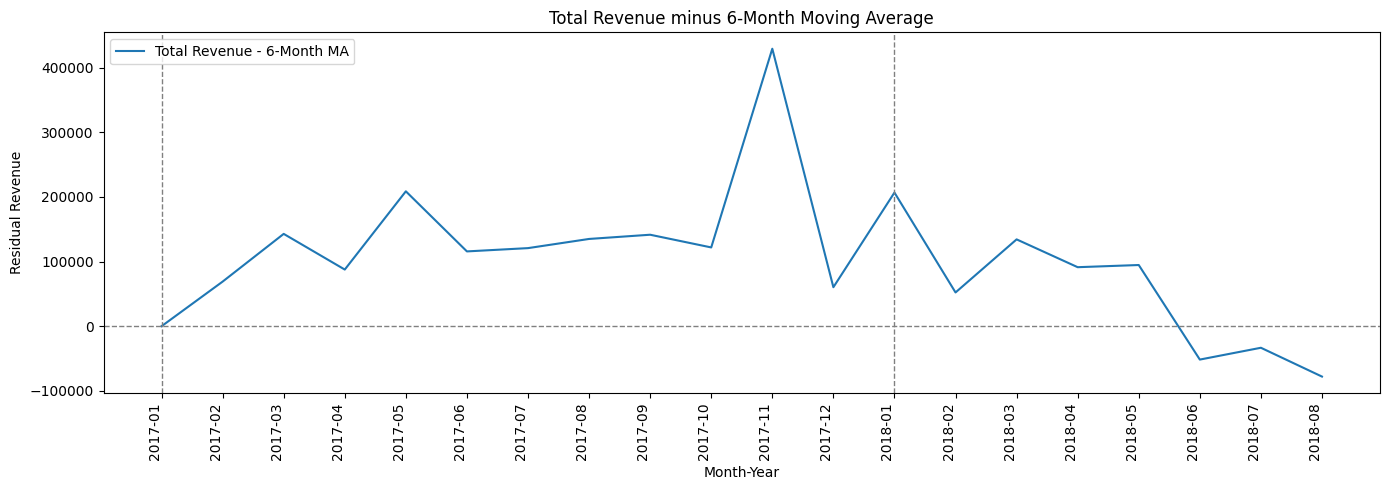

In [5]:
plot_detrended(
    revenue_by_month["sum"], x_labels, year_boundary_positions,
    method="subtract",
    title="Total Revenue minus 6-Month Moving Average",
    ylabel="Residual Revenue",
    label="Total Revenue - 6-Month MA",
)

#### Total Revenue with Trend Removed (Multiplicative Relationship)
Test whether the relationship between seasonality and trends are multiplicative. No clear seasonality pattern.

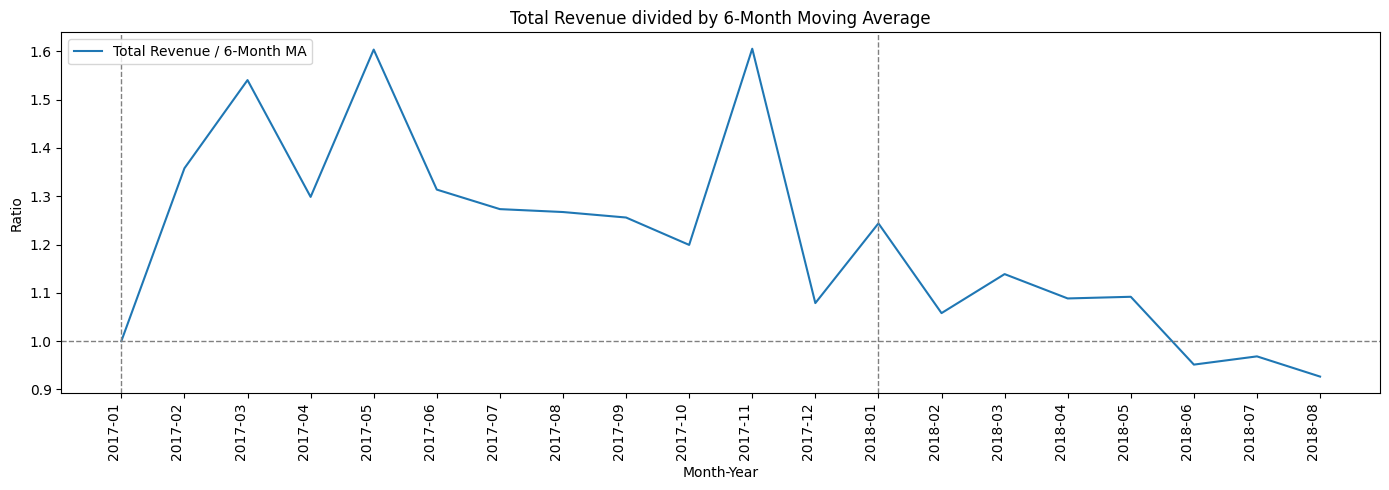

In [6]:
plot_detrended(
    revenue_by_month["sum"], x_labels, year_boundary_positions,
    method="divide",
    title="Total Revenue divided by 6-Month Moving Average",
    ylabel="Ratio",
    label="Total Revenue / 6-Month MA",
)

#### Item Count with Trend Removed (Additive Relationship)
Test whether the relationship between trend and seasonality is additive. No clear seasonality pattern is found

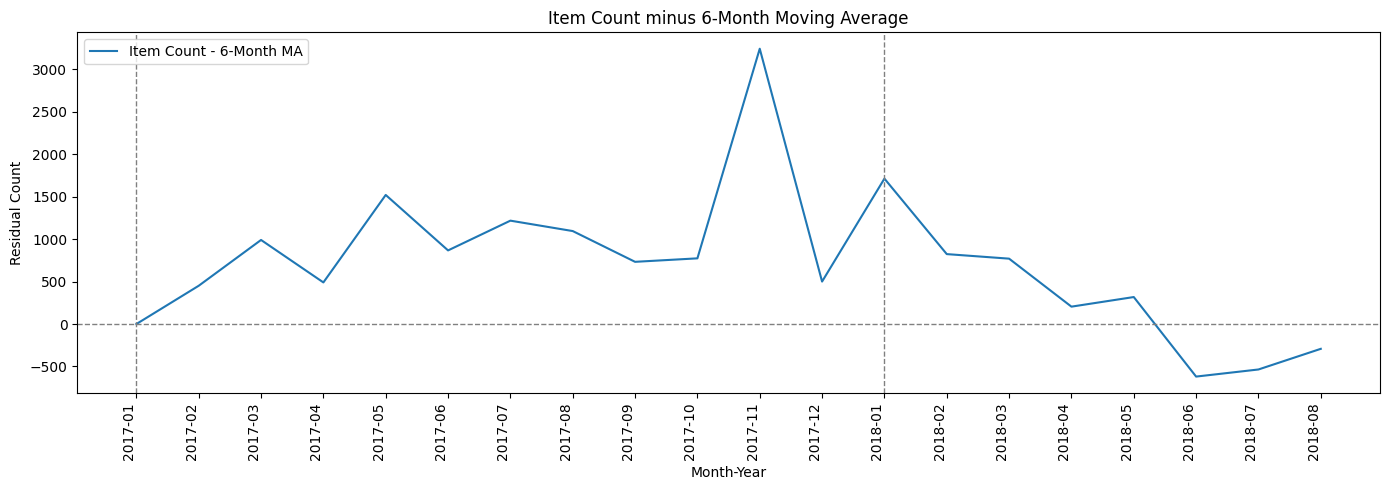

In [7]:
plot_detrended(
    count_by_month, x_labels, year_boundary_positions,
    method="subtract",
    title="Item Count minus 6-Month Moving Average",
    ylabel="Residual Count",
    label="Item Count - 6-Month MA",
)

#### Item Count with Trend Removed (Multiplicative Relationship)
Test whether the relationship between trend and seasonality is multiplicative. No clear seasonality pattern is found

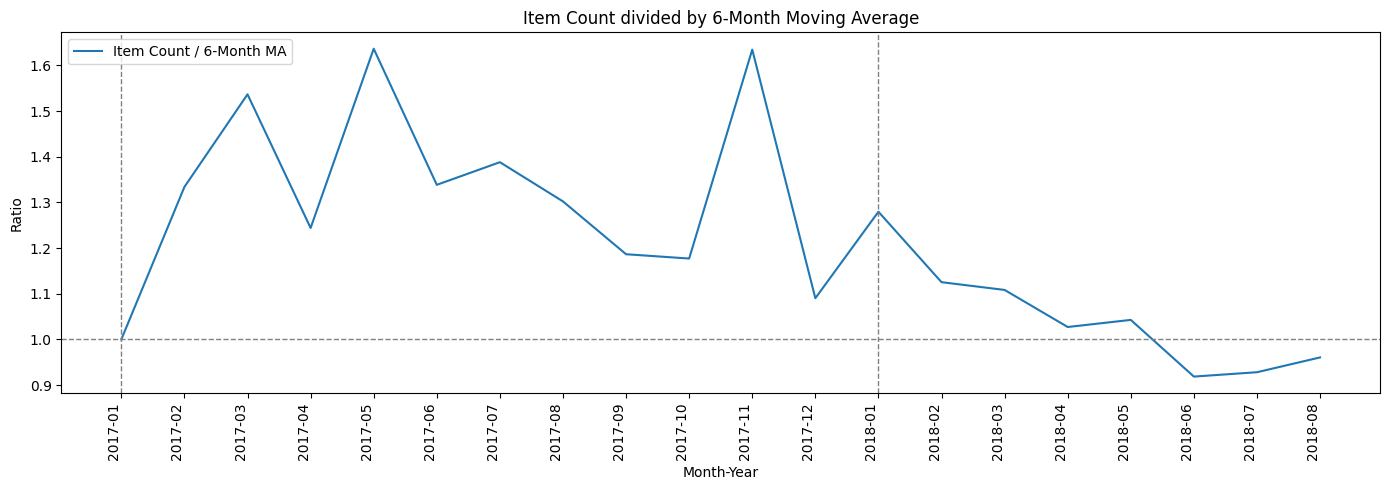

In [8]:
plot_detrended(
    count_by_month, x_labels, year_boundary_positions,
    method="divide",
    title="Item Count divided by 6-Month Moving Average",
    ylabel="Ratio",
    label="Item Count / 6-Month MA",
)

In [9]:
metrics = [
    ("count", "Order Count", "Count"),
    ("avg_revenue", "Average Revenue", "Avg Revenue"),
    ("total_revenue", "Total Revenue", "Total Revenue"),
]

## 1. Revenue by State
SP is the dominant state, consistently contributing around 65% of both total revenue and order count. Both SP and Other States grow in absolute terms, but SP's lead is structural and does not erode over time. Average revenue per item is similar between the two groups, confirming SP's dominance is volume-driven rather than higher-priced items.

In [10]:
df["sp_vs_other"] = df["state"].where(df["state"] == "SP", other="Other States")

sp_month = monthly_agg(df, "sp_vs_other")
sp_groups = ["SP", "Other States"]
sp_colors = {"SP": "steelblue", "Other States": "orange"}

### Monthly Count, Mean, and Total Revenue by States
SP leads on all three metrics. Count and total revenue for both groups grow steadily, with SP maintaining a consistent multiple over Other States. Average revenue per item is comparable between the two groups.

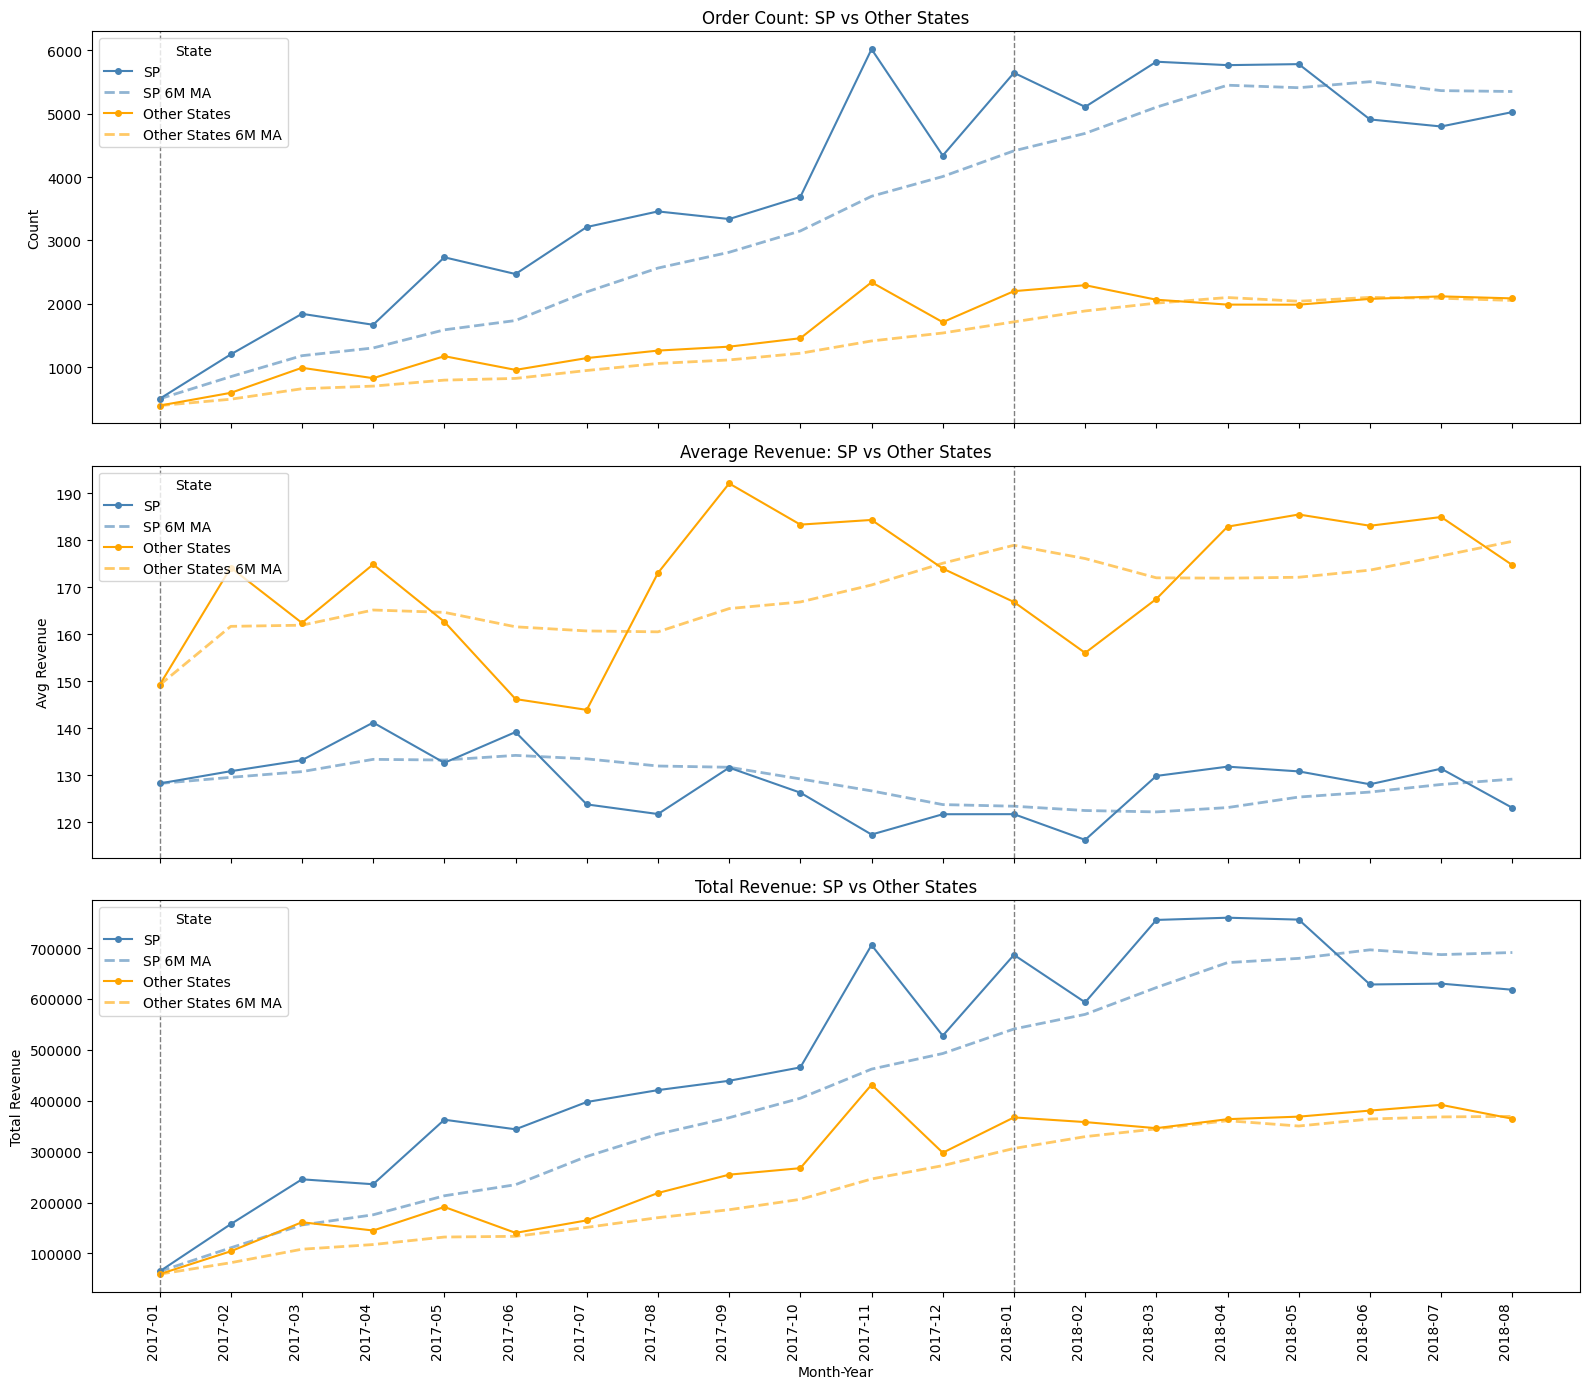

In [11]:
plot_timeseries_with_ma(
    sp_month, sp_groups, "sp_vs_other", sp_colors, metrics, year_boundary_positions,
    ma_window=6, legend_title="State", title_suffix=": SP vs Other States",
)

### Revenue Share by States
SP's share of total revenue and order count remains stable at around 65% throughout the period, with no sign of increase or decrease. This indicates SP's dominance is structural and not driven by a temporary surge.

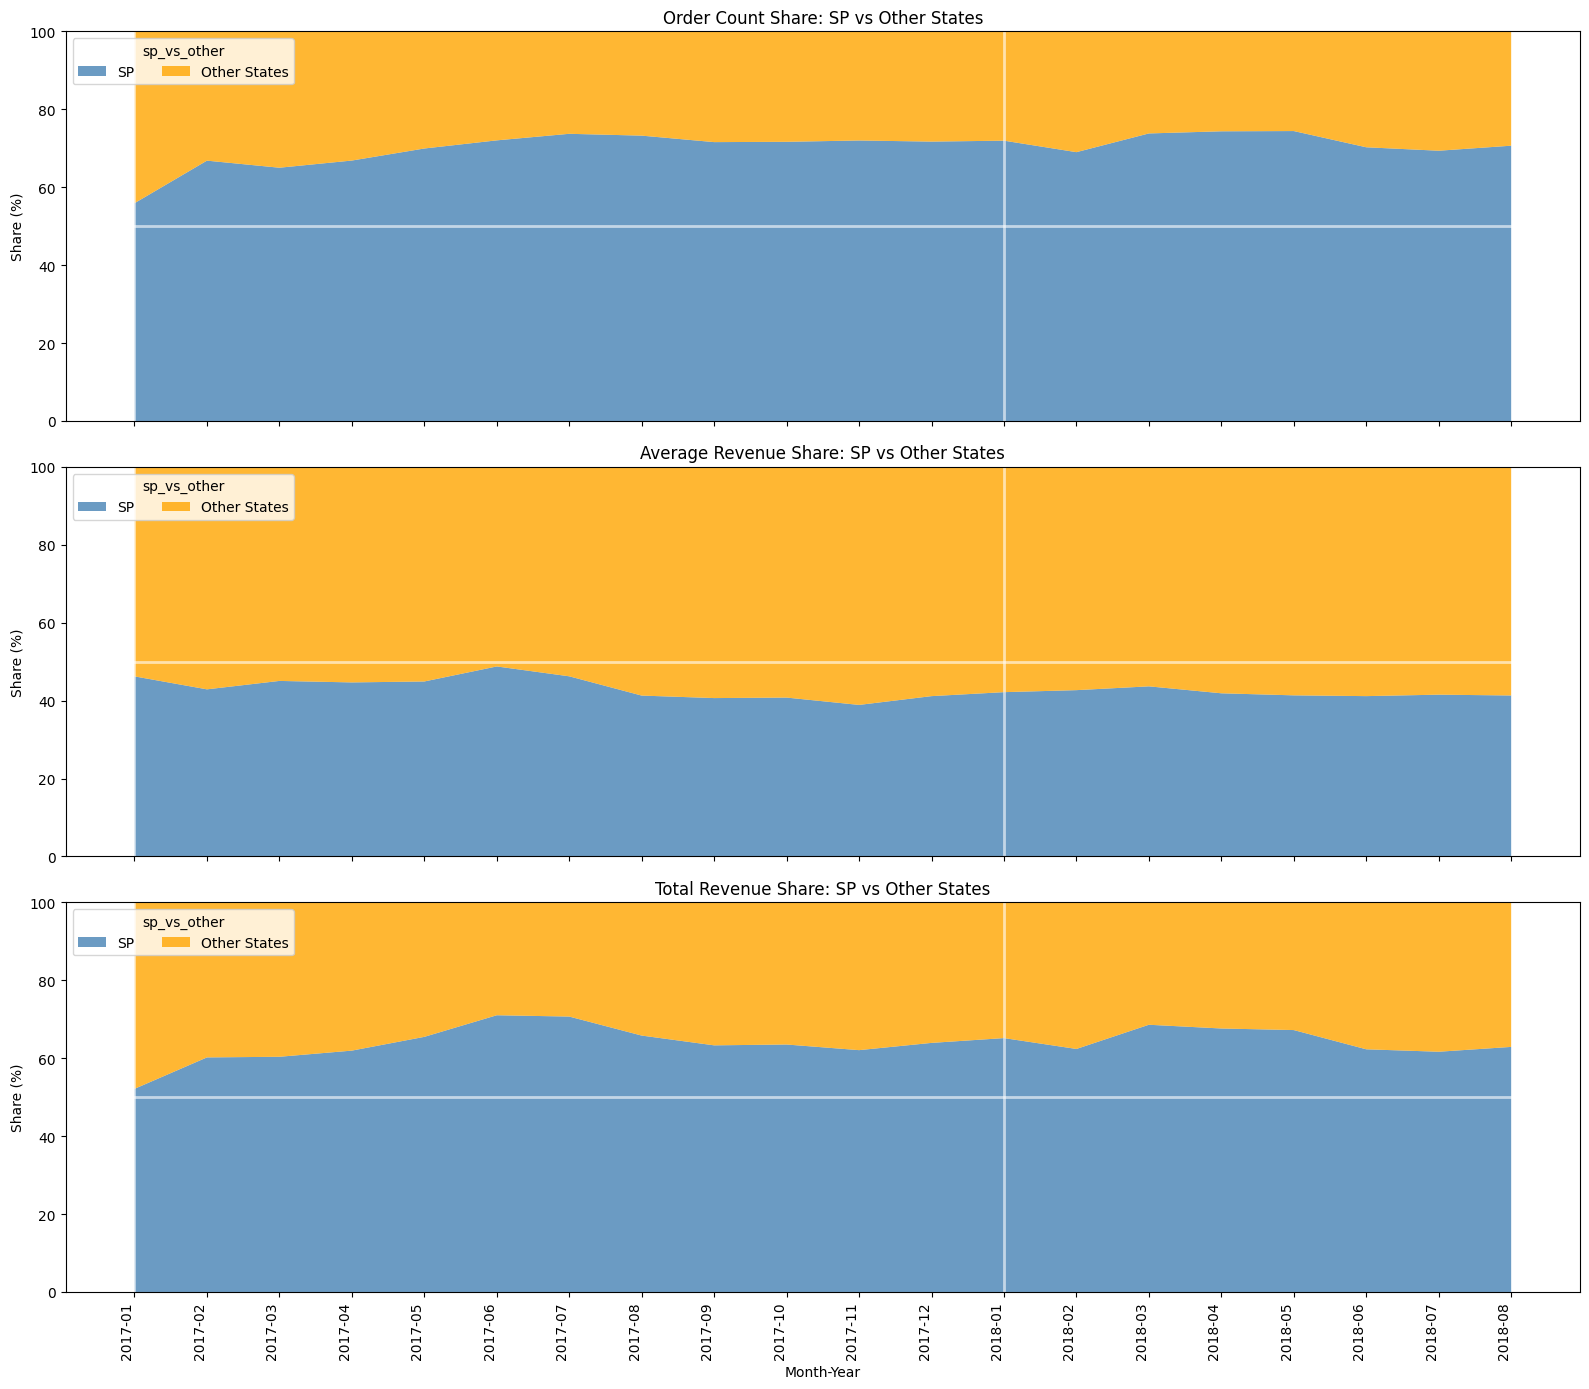

In [12]:
plot_stacked_pct(sp_month, sp_groups, "sp_vs_other", sp_colors, metrics, year_boundary_positions,
                 title_suffix=": SP vs Other States")

## 2. Revenue by Category
Selected categories for analysis here is based on the category revenue analysis notebook. Since we have selected the categories by their total revenue share, it is expected that Other categories grow faster in count.

health_beauty is the consistently dominant category across the full period. The top 7 categories maintain a stable combined share of around 50% of total revenue, with no single category growing to dominate the others.

watches_gifts average revenue drops sharply after the first month due to low initial count. As volume grows, the average converges to its true distribution mean.

### Category Trends

In [13]:
# Categories selected in category_revenue_analysis.ipynb: top N by total revenue crossing 50% cumulative share
top_n_categories = [
    "health_beauty",
    "watches_gifts",
    "bed_bath_table",
    "sports_leisure",
    "computers_accessories",
    "furniture_decor",
    "housewares",
]

df["category_grouped"] = df["category"].where(df["category"].isin(top_n_categories), other="Other")
cat_month = monthly_agg(df, "category_grouped")
cat_groups = top_n_categories + ["Other"]

cat_colors = dict(zip(top_n_categories, plt.cm.tab10.colors[:len(top_n_categories)]))
cat_colors["Other"] = (0.6, 0.6, 0.6, 1.0)

# Collapse top 7 into a single group for this overview plot.
# avg_revenue is recomputed as total_revenue / count to avoid an unweighted mean-of-means.
top7_vs_other_month = (
	cat_month.copy()
	.assign(group=lambda d: d["category_grouped"].where(d["category_grouped"] == "Other", other="Top 7"))
	.groupby(["month_year", "group"])[["count", "total_revenue"]]
	.sum()
	.reset_index()
)
top7_vs_other_month["avg_revenue"] = top7_vs_other_month["total_revenue"] / top7_vs_other_month["count"]
top7_vs_other_month["month_year_str"] = top7_vs_other_month["month_year"].astype(str)

t7_groups = ["Top 7", "Other"]
t7_colors = {"Top 7": "steelblue", "Other": "orange"}

### Top 7 Combined vs Other
The top 7 categories combined grow at a similar rate to Other in count, but maintain a consistently higher average revenue per item. Both groups follow the same seasonal pattern for average revenue per order, suggesting seasonality is not specific to the top categories.

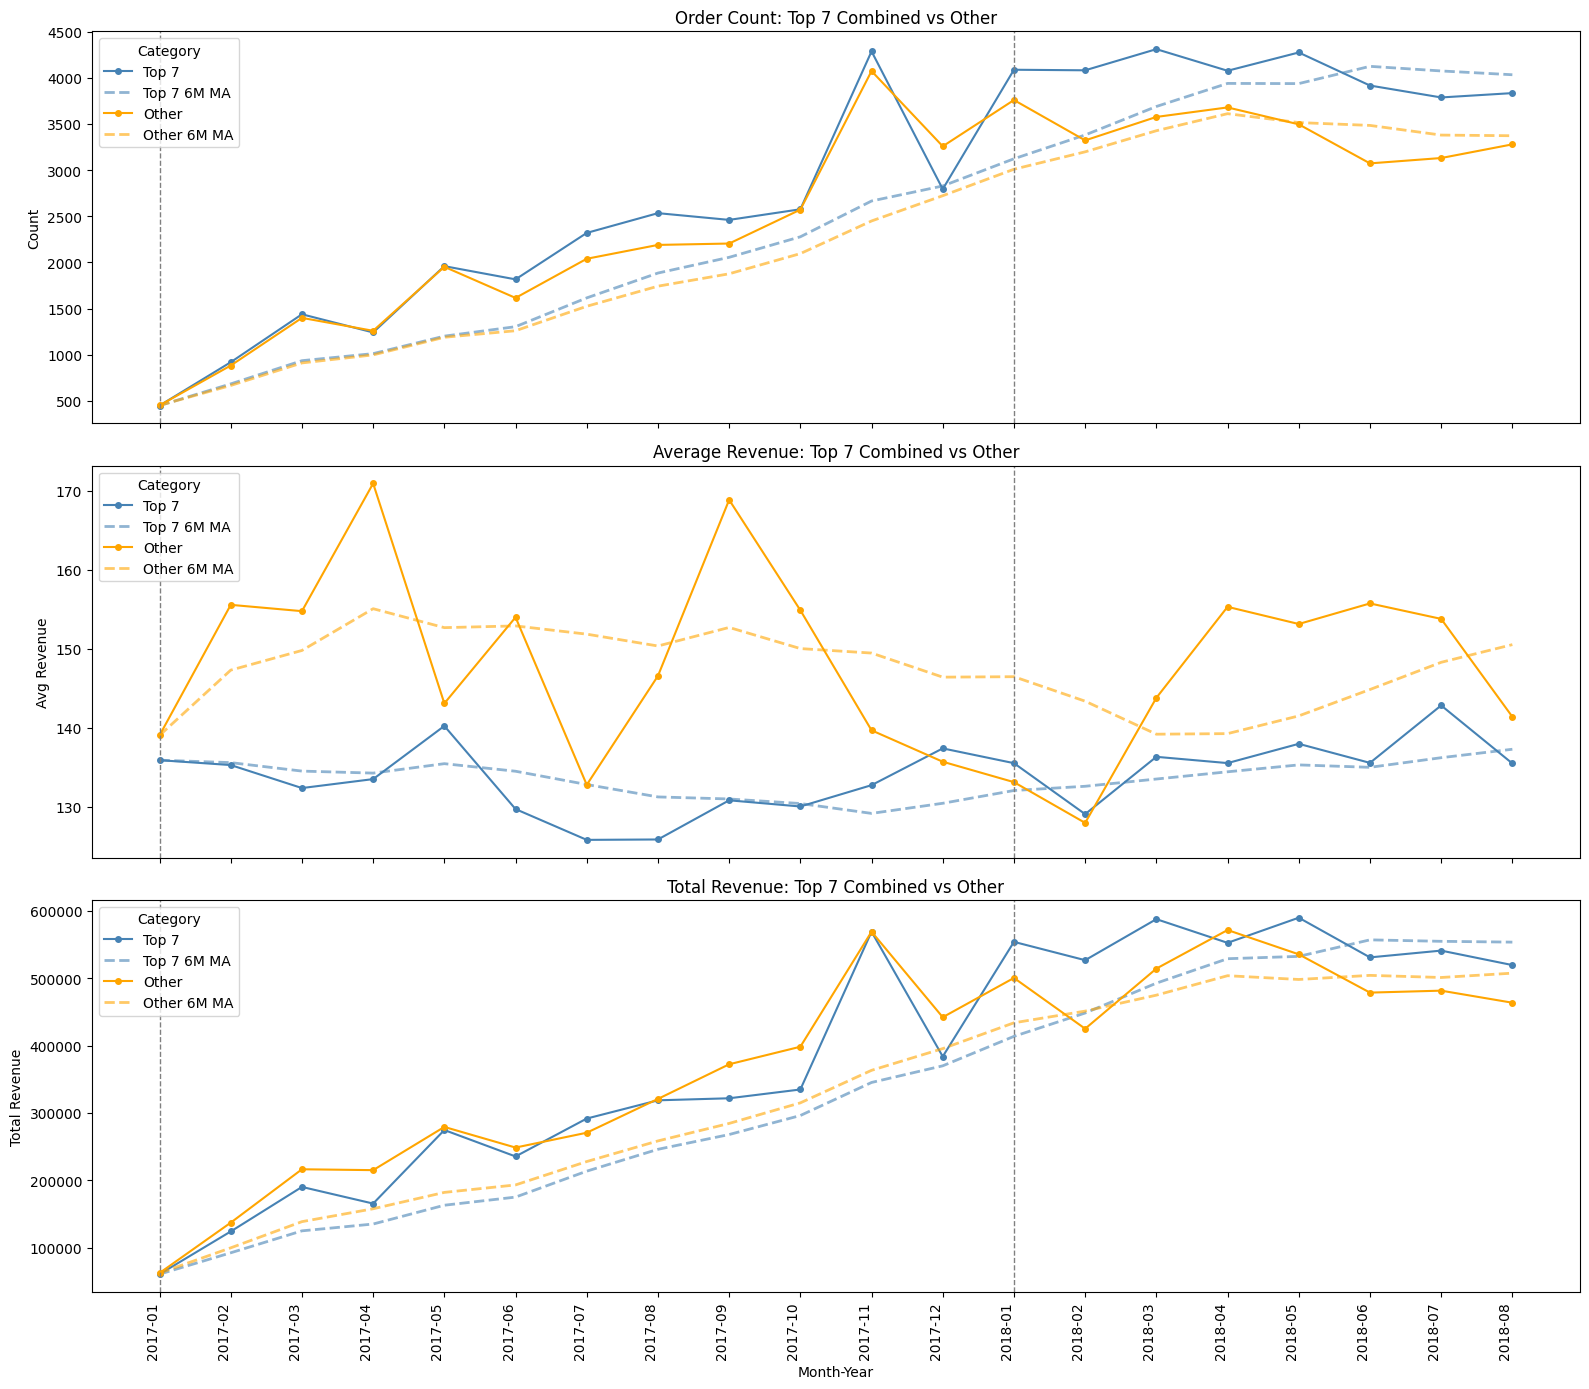

In [14]:
plot_timeseries_with_ma(
	top7_vs_other_month, t7_groups, "group", t7_colors, metrics, year_boundary_positions,
	ma_window=6, legend_title="Category", title_suffix=": Top 7 Combined vs Other",
)

### Individual Category Trends

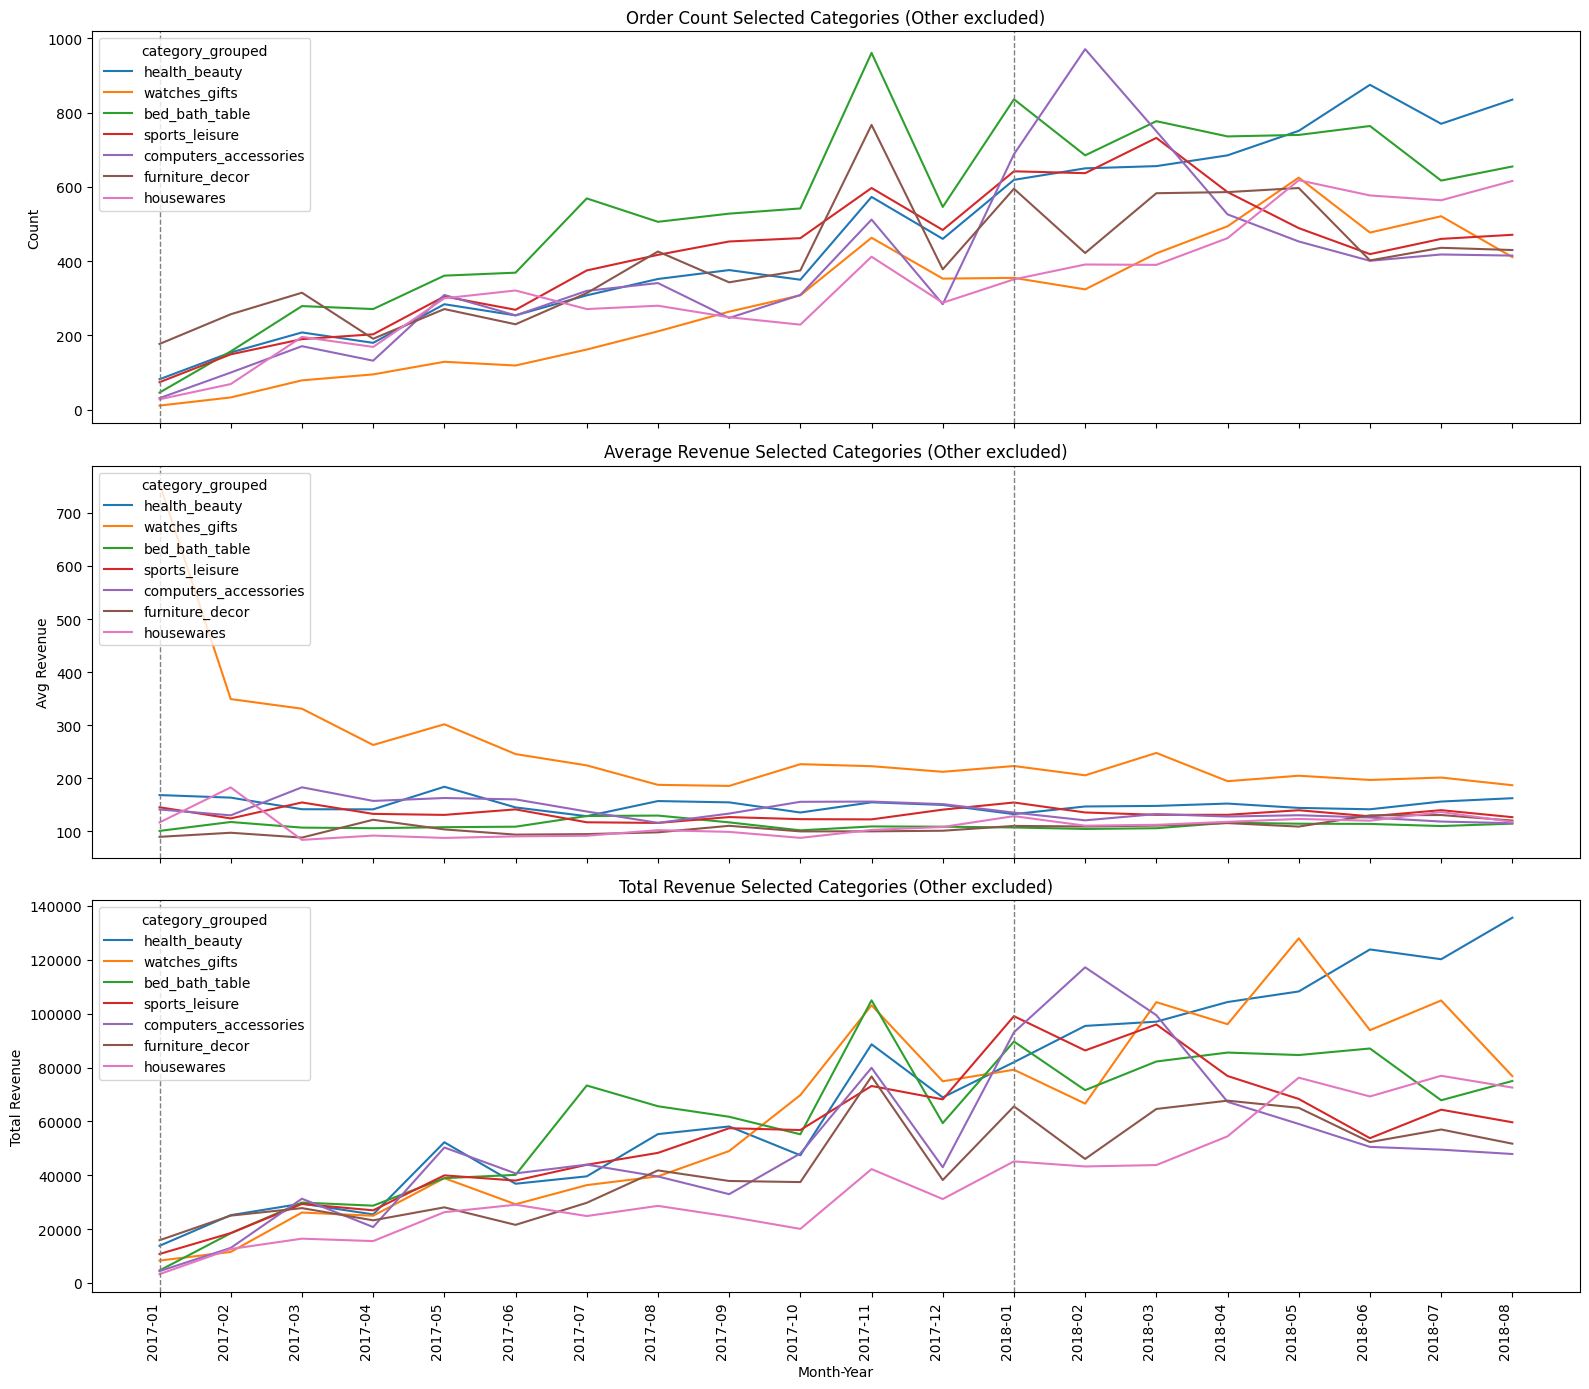

In [15]:
cat_groups_no_other = [c for c in cat_groups if c != "Other"]
cat_month_no_other = cat_month[cat_month["category_grouped"] != "Other"]

line_colors = dict(zip(cat_groups_no_other, plt.cm.tab10.colors[:len(cat_groups_no_other)]))
count_colors = dict(zip(cat_groups_no_other, plt.cm.Pastel1.colors[:len(cat_groups_no_other)]))

plot_category_timeseries(
    cat_month_no_other, cat_groups_no_other, "category_grouped",
    line_colors, count_colors, metrics, year_boundary_positions,
    title_suffix=" Selected Categories (Other excluded)",
    show_count=False,
)

### Individual Category Trends 6-Month MA
The smoothed view confirms the trends above. Growth is consistent across categories with no category showing a sustained decline.

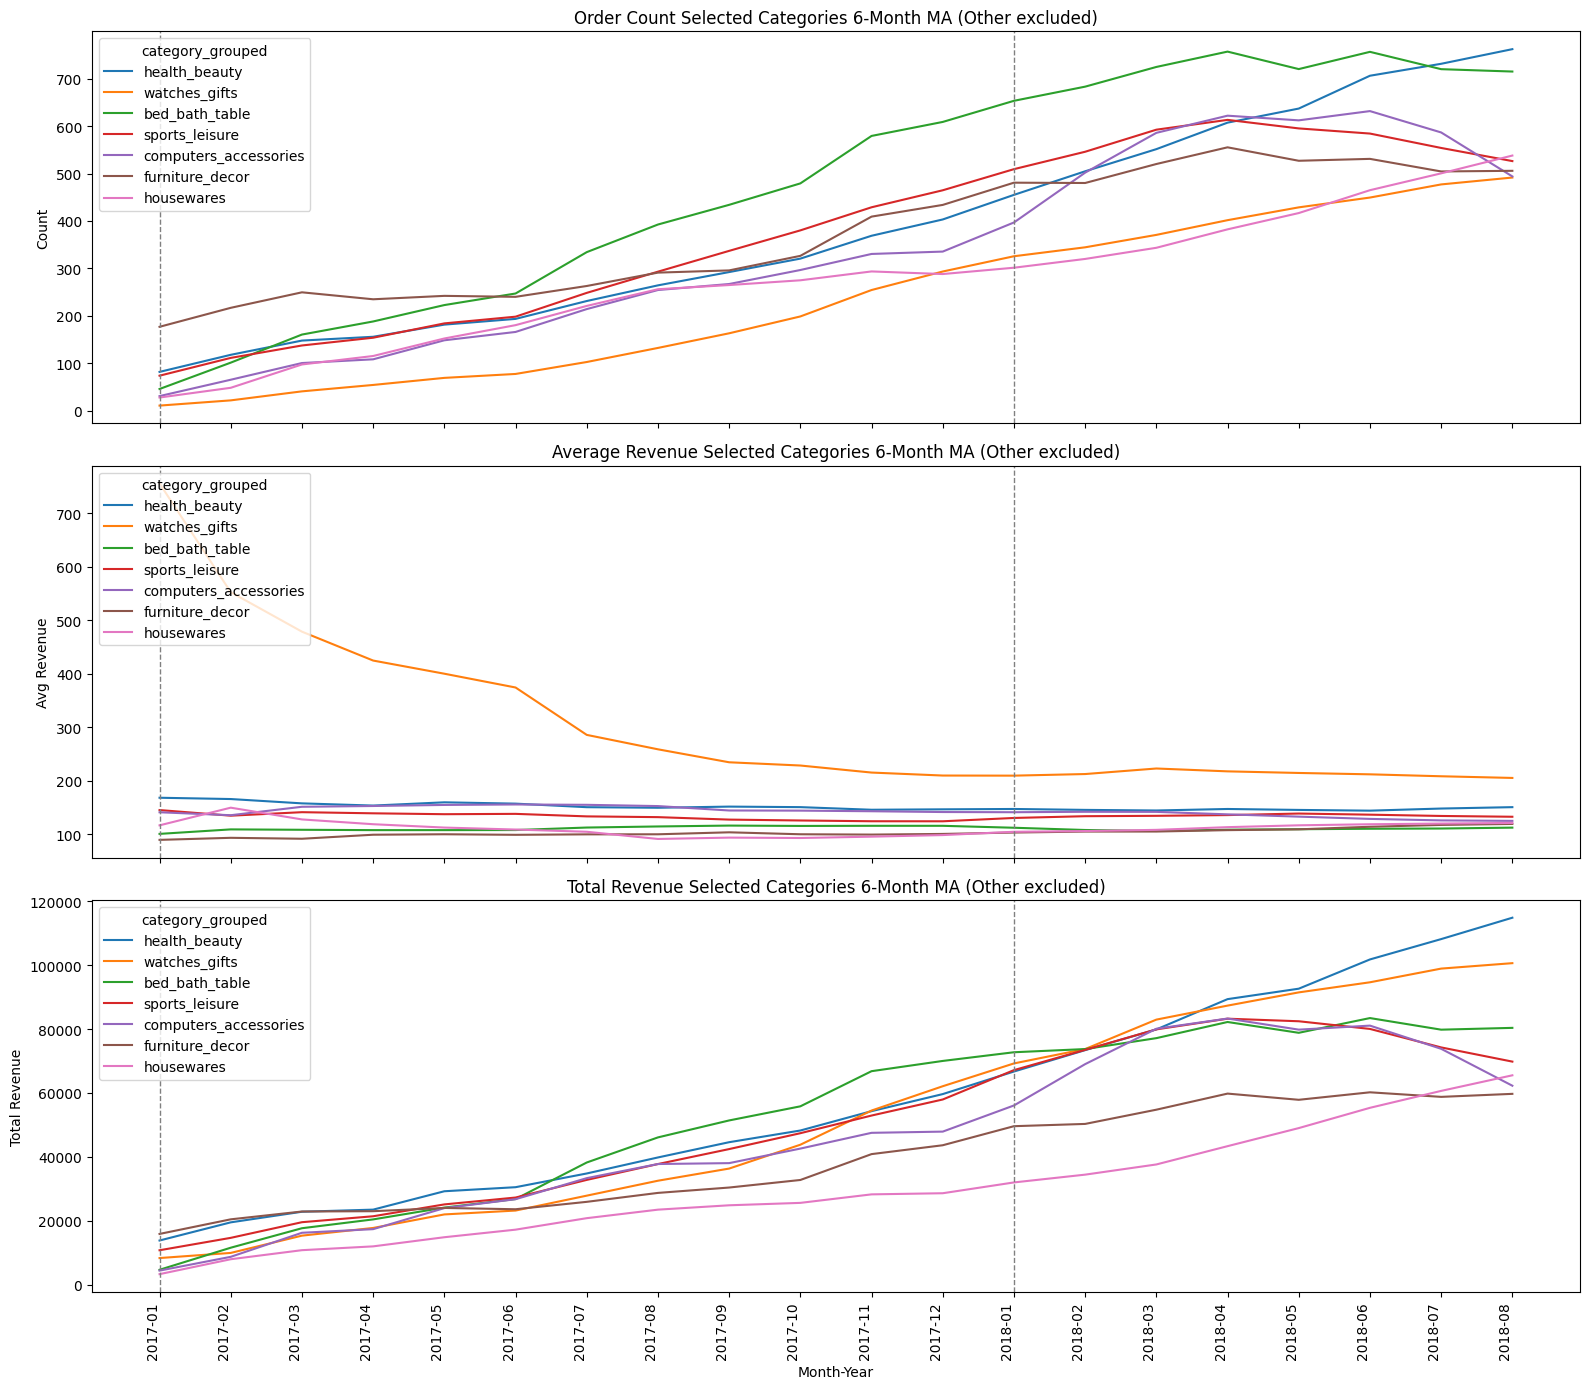

In [16]:
plot_category_timeseries(
    cat_month_no_other, cat_groups_no_other, "category_grouped",
    line_colors, count_colors, metrics, year_boundary_positions,
    title_suffix=" Selected Categories 6-Month MA (Other excluded)",
    smooth=6,
    show_count=False,
)

### Category Share
Within the top 7, category shares are relatively stable over time. No single category shows a strong trend of gaining or losing share.

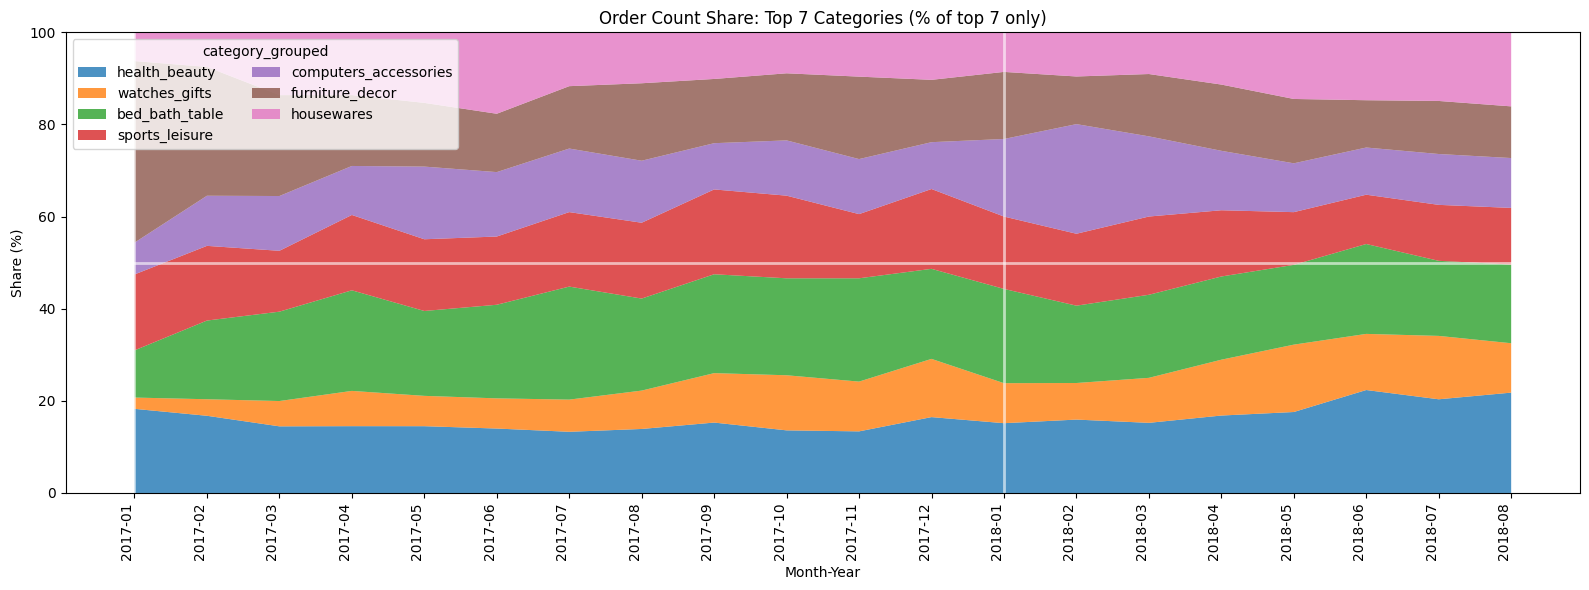

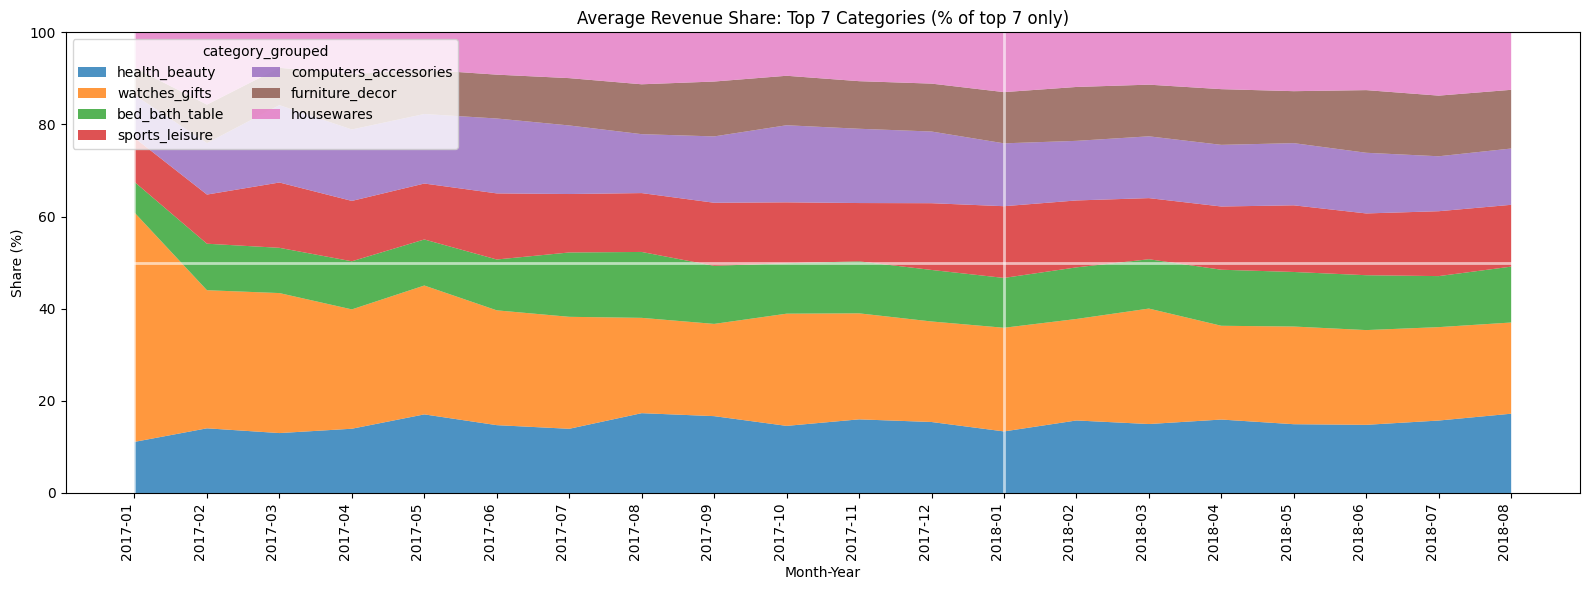

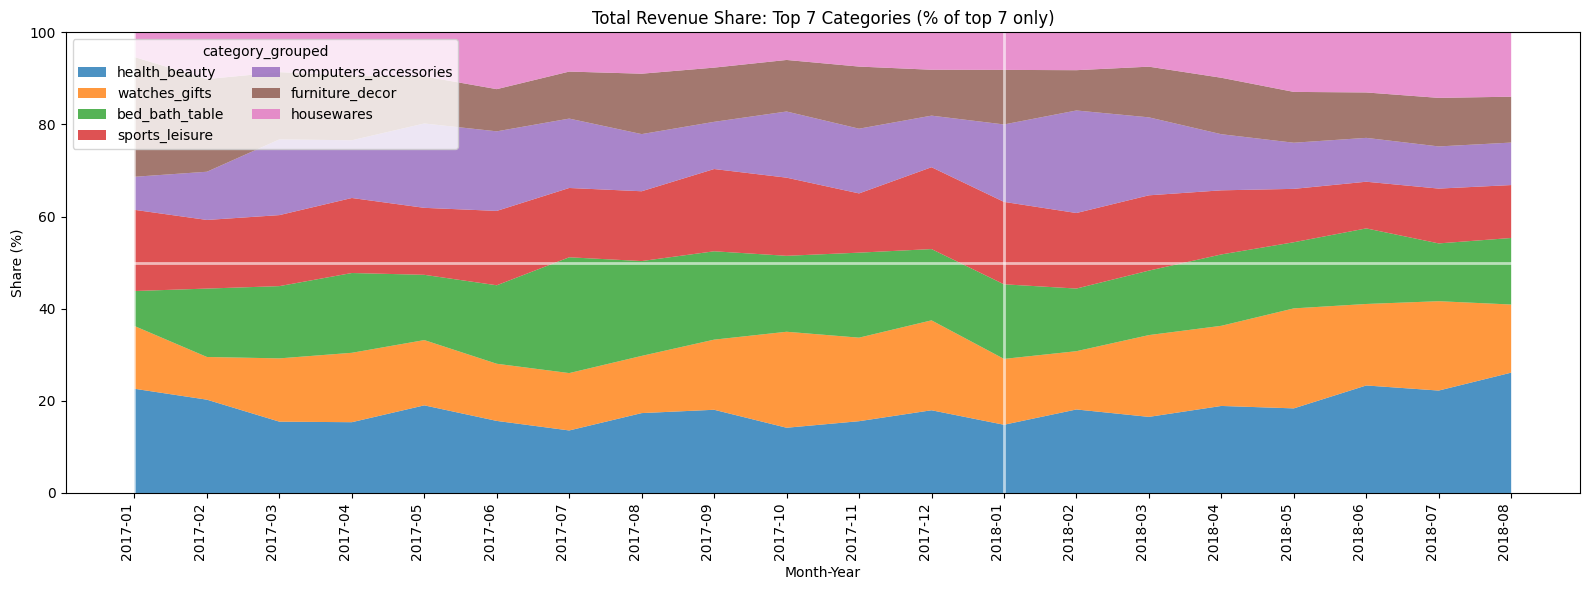

In [17]:
plot_category_share_pct(
	cat_month_no_other, cat_groups_no_other, "category_grouped",
	cat_colors, metrics, year_boundary_positions,
)

### Revenue Share Top 7 Combined vs Other
The top 7 categories collectively hold a stable share of around 50% of total revenue and count throughout the period. This is to be expected since we chose the top category based on revenue share.

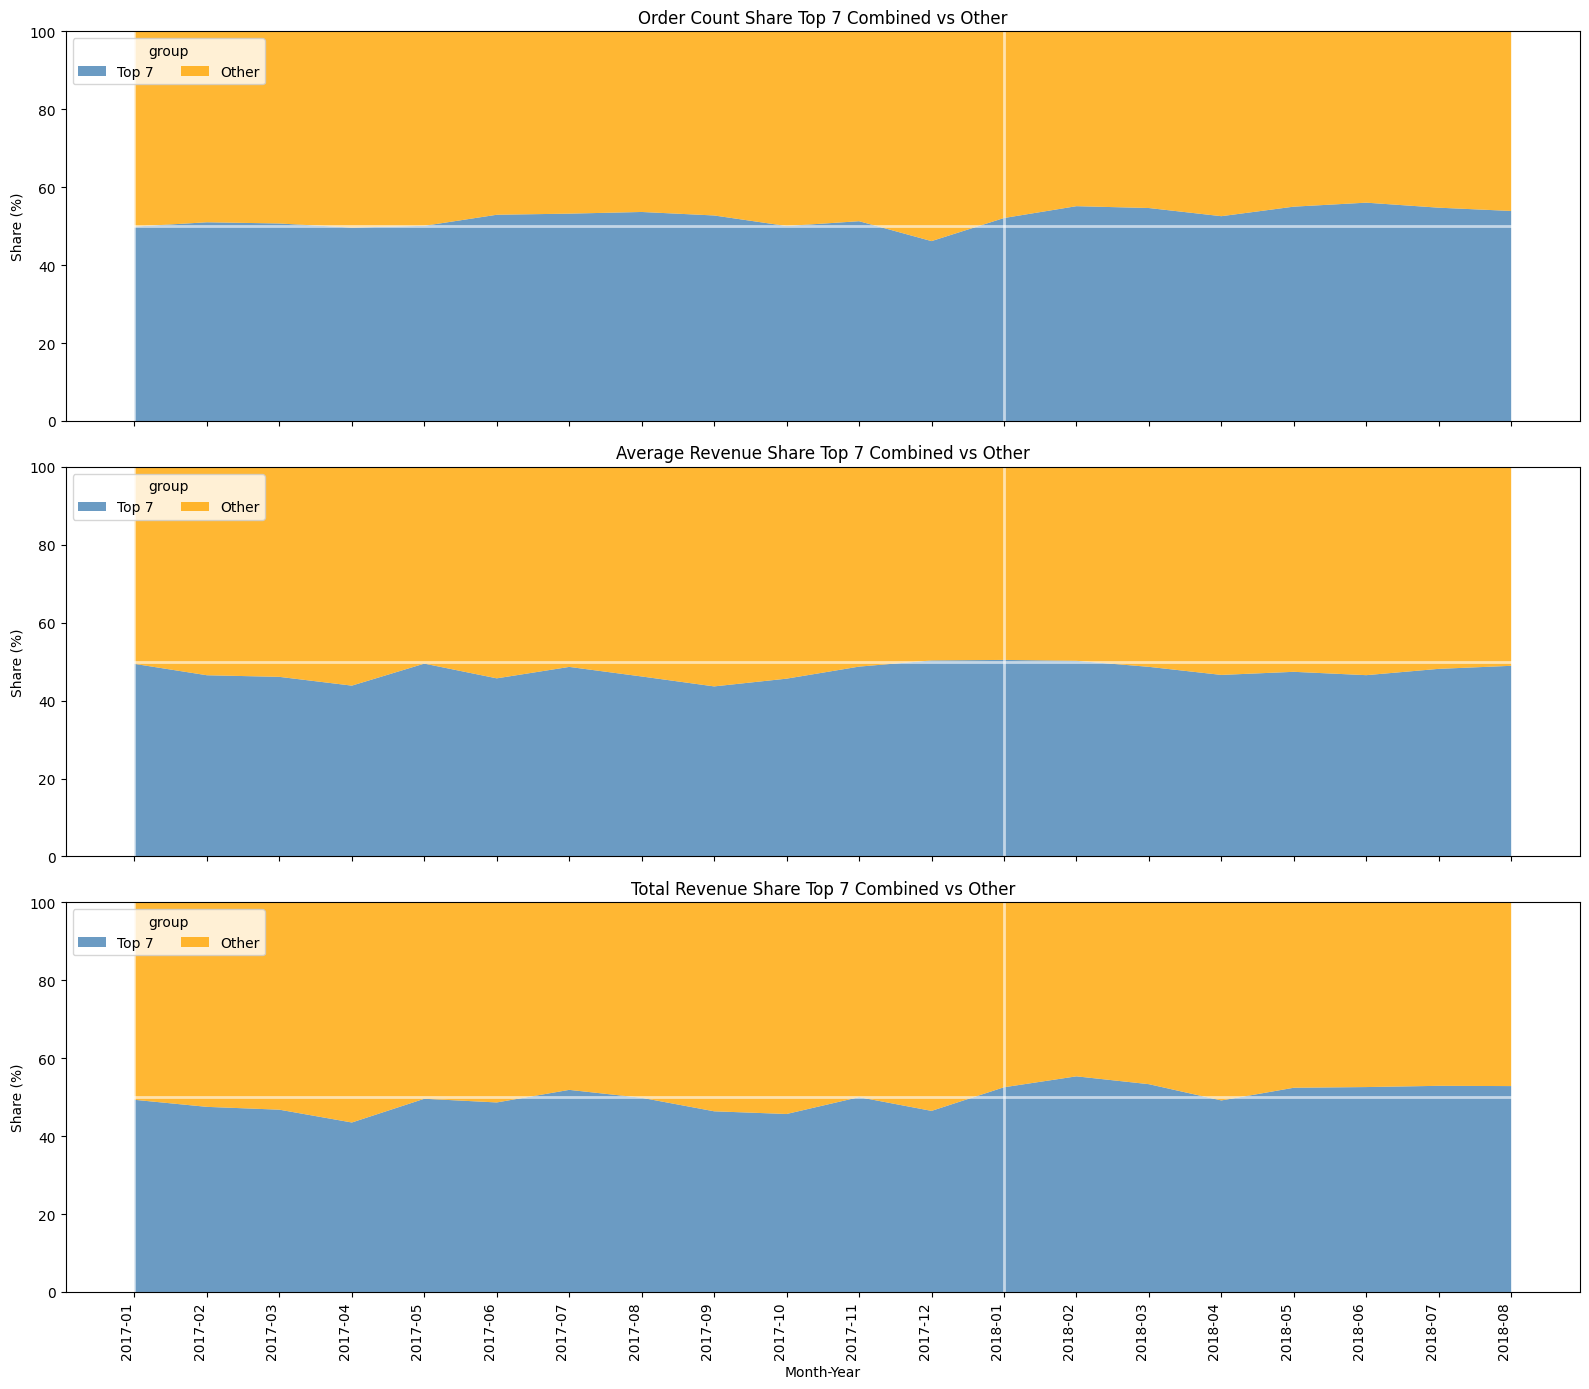

In [18]:
plot_stacked_pct(
	top7_vs_other_month, t7_groups, "group", t7_colors, metrics, year_boundary_positions,
	title_suffix=" Top 7 Combined vs Other",
)